Loading datasets...
Processing annual drug report counts...
Processing annual side-effect report counts...
Calculating shifts between baseline and most recent year...
Generating purposeful visualization layouts...


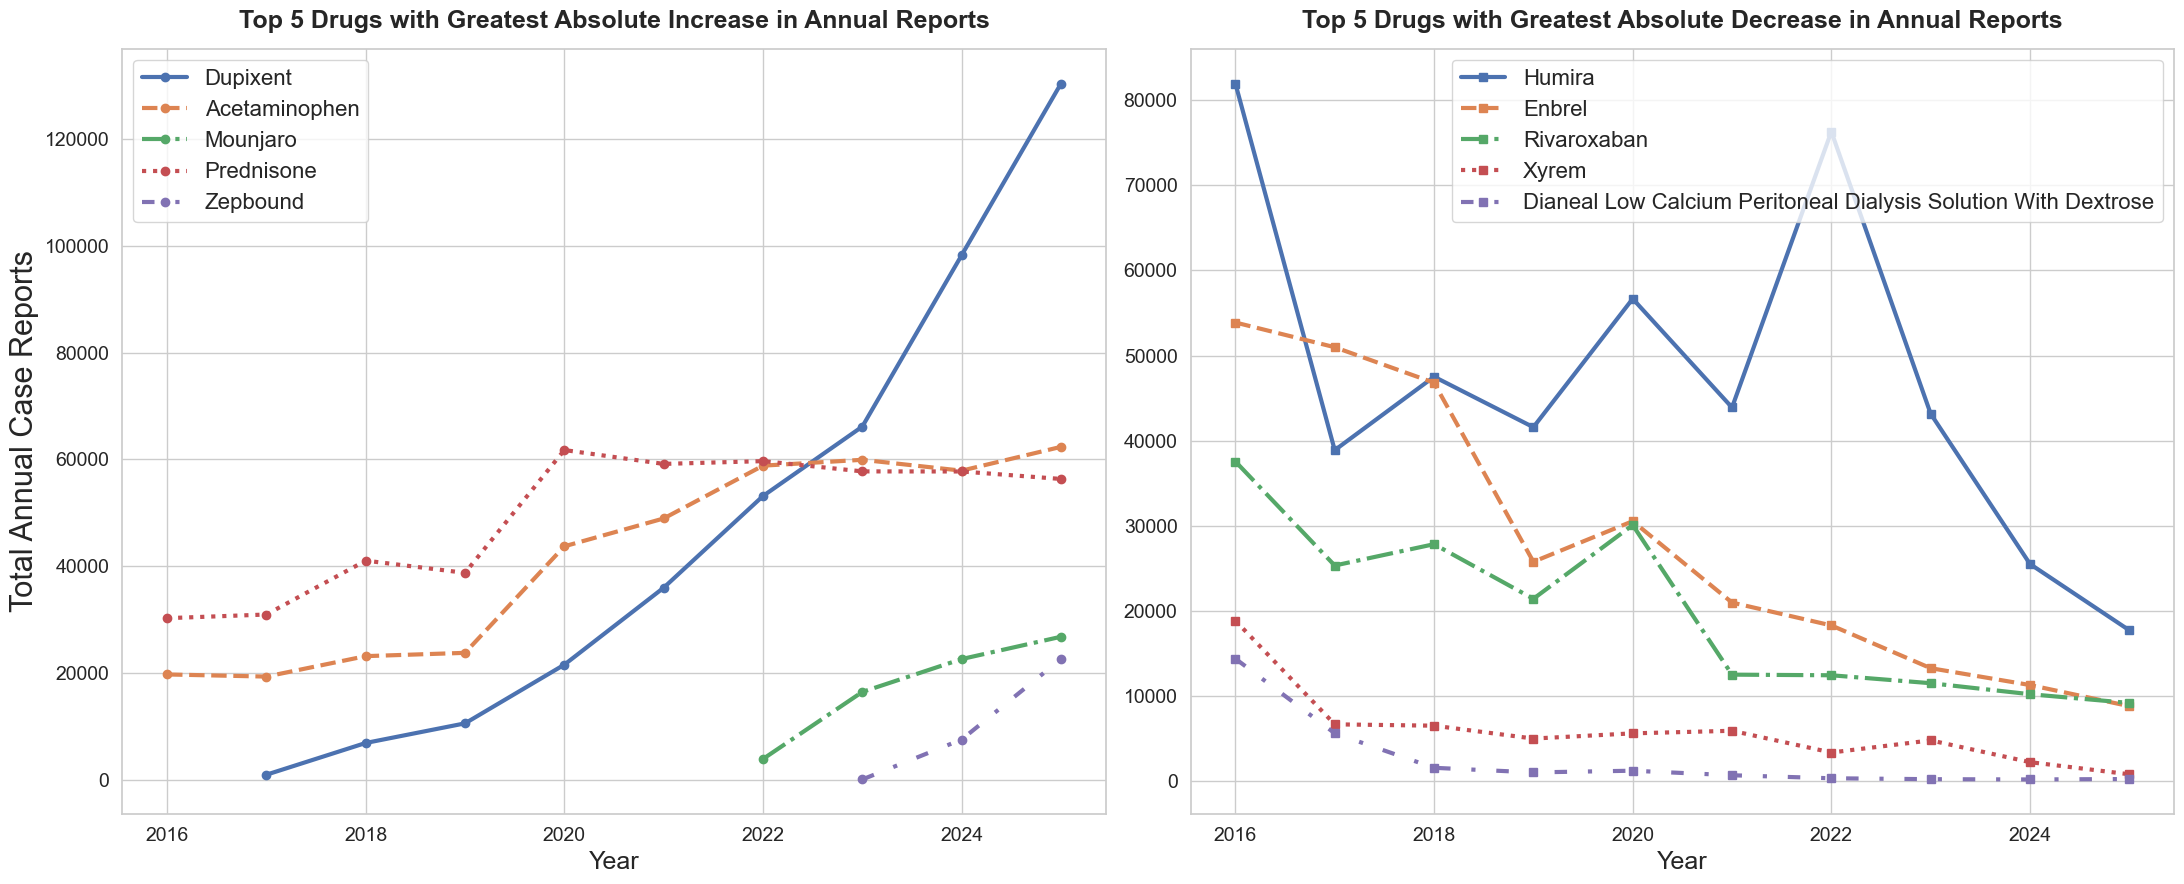

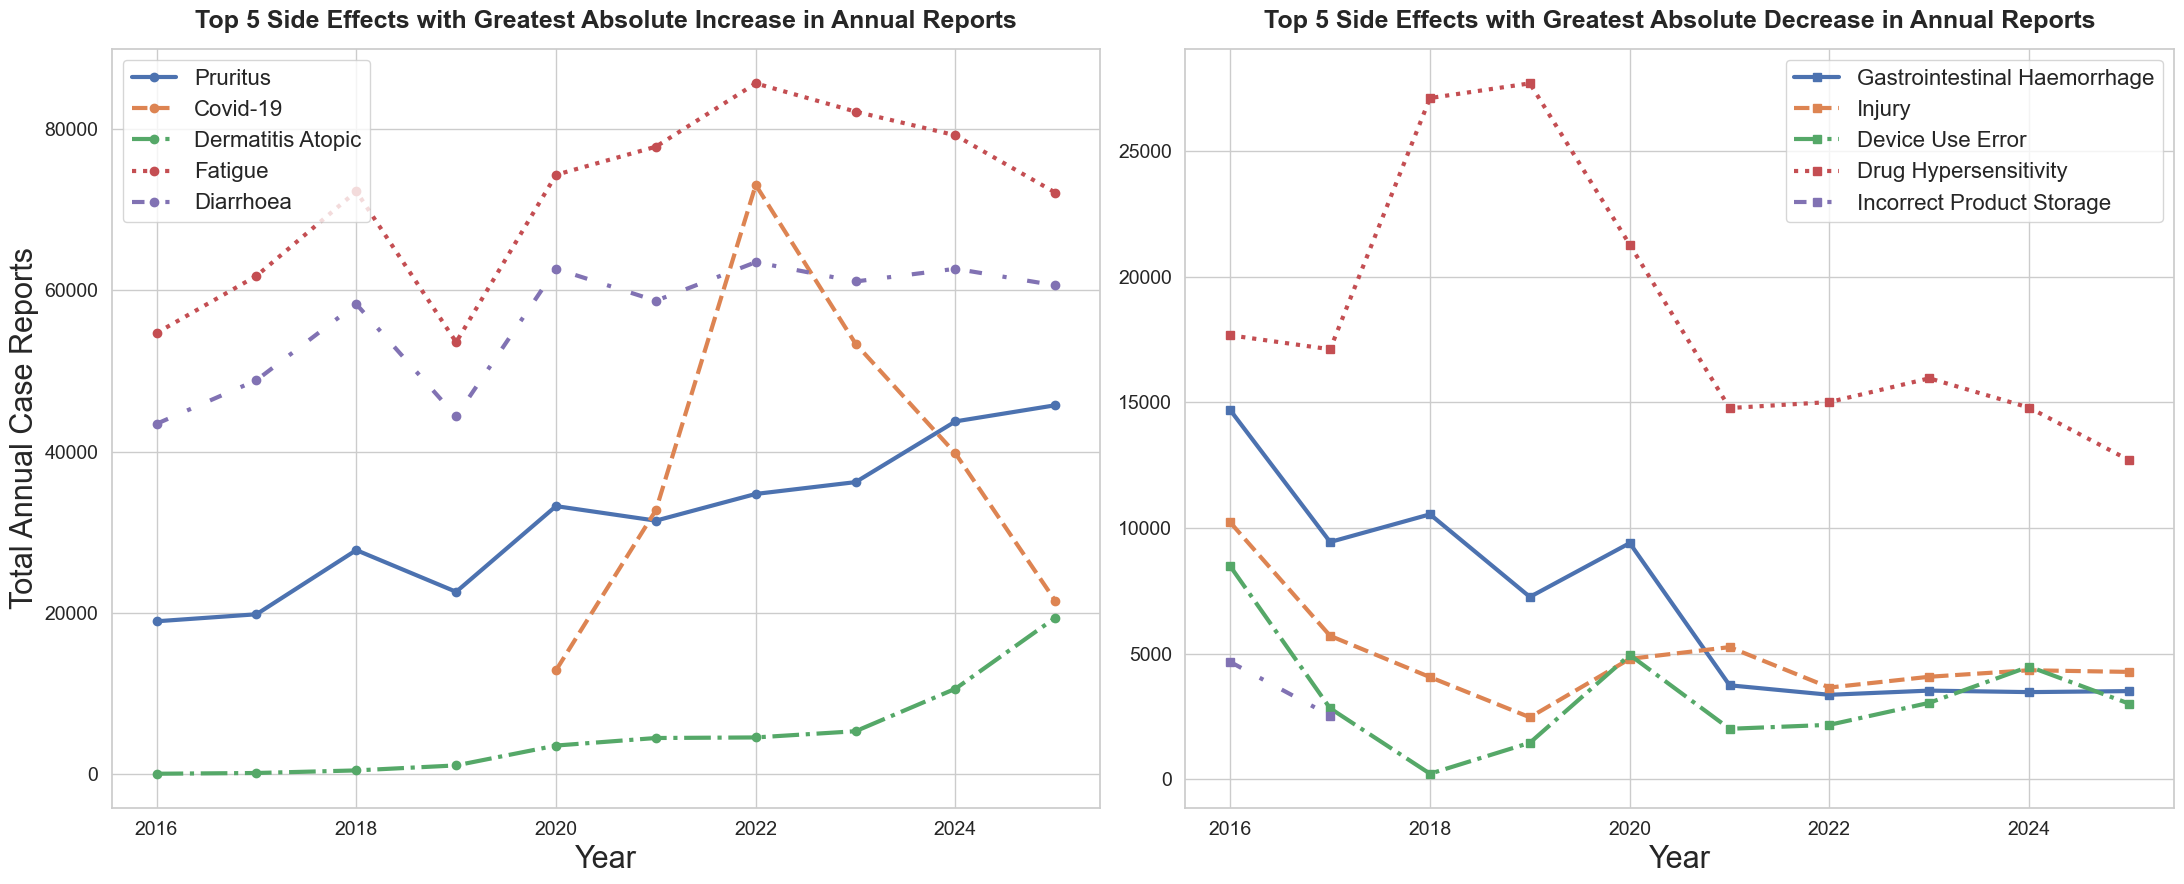

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")
df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/processed/faers_combined_cleaned_pure_reactions.csv')
mapping_df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/processed/drug_name_mapping_updated.csv')
# Build mapping dictionary for high-performance standardized drug lookup
mapping_df['messy_name_clean'] = mapping_df['messy_name'].astype(str).str.strip()
mapping_dict = dict(zip(mapping_df['messy_name_clean'], mapping_df['standardized_name']))


# ==========================================
# 2. DEFINE EXCLUSION LIST & YEAR EXTRACTOR
# ==========================================
# Clear out non-medical / administrative terms from side-effects
adr_exclusion_list = [
    'illness', 
    'condition aggravated', 
    'disease progression', 
    'no adverse event',
    'death'
]

def extract_year(q_str):
    q_clean = str(q_str).strip()
    if len(q_clean) >= 4 and q_clean[:4].isdigit():
        return int(q_clean[:4])
    elif len(q_clean) >= 2 and q_clean[:2].isdigit():
        return int("20" + q_clean[:2])
    return None

df['Year'] = df['quarter'].apply(extract_year)
df = df.dropna(subset=['Year'])
df = df[df['Year'] != 2026] # Exclude 2026 since only Q1

# ==========================================
# 3. PROCESS ANNUAL DRUG COUNTS
# ==========================================
print("Processing annual drug report counts...")
drug_records = []

for idx, row in df[['Year', 'drug_combination']].dropna().iterrows():
    yr = row['Year']
    raw_drugs = [d.strip() for d in str(row['drug_combination']).split(';') if d.strip()]
    
    for d in raw_drugs:
        standardized = mapping_dict.get(d)
        drug_name = str(standardized).lower() if (pd.notna(standardized) and standardized) else d.lower()
        drug_records.append({'Year': yr, 'Drug': drug_name.title()})

drug_annual_df = pd.DataFrame(drug_records)
drug_counts = drug_annual_df.groupby(['Year', 'Drug']).size().reset_index(name='Annual_Count')


# ==========================================
# 4. PROCESS ANNUAL ADR COUNTS
# ==========================================
print("Processing annual side-effect report counts...")
adr_records = []

for idx, row in df[['Year', 'adrs']].dropna().iterrows():
    yr = row['Year']
    raw_adrs = [a.strip().lower() for a in str(row['adrs']).split(';') if a.strip()]
    
    for a in raw_adrs:
        if a not in adr_exclusion_list:
            adr_records.append({'Year': yr, 'ADR': a.title()})

adr_annual_df = pd.DataFrame(adr_records)
adr_counts = adr_annual_df.groupby(['Year', 'ADR']).size().reset_index(name='Annual_Count')


# ==========================================
# 5. CALCULATE ABSOLUTE SHIFTS (DELTAS)
# ==========================================
print("Calculating shifts between baseline and most recent year...")
years_sorted = sorted(df['Year'].unique())
start_yr, end_yr = years_sorted[0], years_sorted[-1]

# --- Drug Deltas ---
d_start = drug_counts[drug_counts['Year'] == start_yr][['Drug', 'Annual_Count']].rename(columns={'Annual_Count': 'Start_Vol'})
d_end = drug_counts[drug_counts['Year'] == end_yr][['Drug', 'Annual_Count']].rename(columns={'Annual_Count': 'End_Vol'})
d_shift = pd.merge(d_start, d_end, on='Drug', how='outer').fillna(0)
d_shift['Delta'] = d_shift['End_Vol'] - d_shift['Start_Vol']

top_drug_inc = d_shift.sort_values(by='Delta', ascending=False).head(5)['Drug'].tolist()
top_drug_dec = d_shift.sort_values(by='Delta', ascending=True).head(5)['Drug'].tolist()

# --- ADR Deltas ---
a_start = adr_counts[adr_counts['Year'] == start_yr][['ADR', 'Annual_Count']].rename(columns={'Annual_Count': 'Start_Vol'})
a_end = adr_counts[adr_counts['Year'] == end_yr][['ADR', 'Annual_Count']].rename(columns={'Annual_Count': 'End_Vol'})
a_shift = pd.merge(a_start, a_end, on='ADR', how='outer').fillna(0)
a_shift['Delta'] = a_shift['End_Vol'] - a_shift['Start_Vol']

top_adr_inc = a_shift.sort_values(by='Delta', ascending=False).head(5)['ADR'].tolist()
top_adr_dec = a_shift.sort_values(by='Delta', ascending=True).head(5)['ADR'].tolist()


# ==========================================
# 6. MINIMALIST VISUALIZATION GENERATION
# ==========================================
print("Generating purposeful visualization layouts...")
sns.set_theme(style="whitegrid")
line_styles = ["-", "--", "-.", ":", (0, (3, 5, 1, 5))]

# Figure 1: Drug Volumes (Top Increasers vs Decreasers)
fig1, axes1 = plt.subplots(1, 2, figsize=(22, 9))

for i, item in enumerate(top_drug_inc):
    sub = drug_counts[drug_counts['Drug'] == item].sort_values('Year')
    axes1[0].plot(sub['Year'], sub['Annual_Count'], label=item, linestyle=line_styles[i % 5], marker='o', linewidth=3)
axes1[0].set_title('Top 5 Drugs with Greatest Absolute Increase in Annual Reports', fontsize=18, fontweight='bold', pad=15)
axes1[0].set_ylabel('Total Annual Case Reports', fontsize=22)
axes1[0].set_xlabel('Year', fontsize=18)
axes1[0].legend(fontsize=16, loc='upper left')

for i, item in enumerate(top_drug_dec):
    sub = drug_counts[drug_counts['Drug'] == item].sort_values('Year')
    axes1[1].plot(sub['Year'], sub['Annual_Count'], label=item, linestyle=line_styles[i % 5], marker='s', linewidth=3)
axes1[1].set_title('Top 5 Drugs with Greatest Absolute Decrease in Annual Reports', fontsize=18, fontweight='bold', pad=15)
axes1[1].set_xlabel('Year', fontsize=18)
axes1[1].legend(fontsize=16, loc='upper right')

for ax in axes1:
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.tick_params(labelsize=14)

plt.tight_layout()

# Figure 2: ADR Volumes (Top Increasers vs Decreasers)
fig2, axes2 = plt.subplots(1, 2, figsize=(22, 9))

for i, item in enumerate(top_adr_inc):
    sub = adr_counts[adr_counts['ADR'] == item].sort_values('Year')
    axes2[0].plot(sub['Year'], sub['Annual_Count'], label=item, linestyle=line_styles[i % 5], marker='o', linewidth=3)
axes2[0].set_title('Top 5 Side Effects with Greatest Absolute Increase in Annual Reports', fontsize=18, fontweight='bold', pad=15)
axes2[0].set_ylabel('Total Annual Case Reports', fontsize=22)
axes2[0].set_xlabel('Year', fontsize=22)
axes2[0].legend(fontsize=16, loc='upper left')

for i, item in enumerate(top_adr_dec):
    sub = adr_counts[adr_counts['ADR'] == item].sort_values('Year')
    axes2[1].plot(sub['Year'], sub['Annual_Count'], label=item, linestyle=line_styles[i % 5], marker='s', linewidth=3)
axes2[1].set_title('Top 5 Side Effects with Greatest Absolute Decrease in Annual Reports', fontsize=18, fontweight='bold', pad=15)
axes2[1].set_xlabel('Year', fontsize=22)
axes2[1].legend(fontsize=16, loc='upper right')

for ax in axes2:
    ax.xaxis.get_major_locator().set_params(integer=True)
    ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()